In [19]:
# ============================================
# SECTION 1 : IMPORTS DES LIBRAIRIES
# ============================================

# Manipulation de données
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt
import seaborn as sns

# Utilitaires
import warnings
from datetime import datetime

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Vérification des versions
print("="*60)
print("CONFIGURATION RÉUSSIE")
print("="*60)
print(f"Pandas version   : {pd.__version__}")
print(f"Numpy version    : {np.__version__}")
print(f"Matplotlib version : importée avec succès")
print(f"Seaborn version  : importée avec succès")
print("="*60)
print(f"Date/Heure : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)


CONFIGURATION RÉUSSIE
Pandas version   : 2.3.3
Numpy version    : 2.3.4
Matplotlib version : importée avec succès
Seaborn version  : importée avec succès
Date/Heure : 2026-02-14 19:10:16


In [20]:
# ============================================
# SECTION 2 : CHARGEMENT DES DONNÉES
# ============================================

# Chemin vers le fichier
data_path = 'Data/spg.csv'

# Chargement du dataset
df = pd.read_csv(data_path)

print("="*60)
print(" DATASET CHARGÉ AVEC SUCCÈS")
print("="*60)

# Informations générales
print(f"\n Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille en mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Aperçu des premières lignes
print("\n" + "="*60)
print("APERÇU DES 5 PREMIÈRES LIGNES")
print("="*60)
print(df.head())



 DATASET CHARGÉ AVEC SUCCÈS

 Dimensions du dataset : 4213 lignes × 21 colonnes
 Taille en mémoire : 0.68 MB

APERÇU DES 5 PREMIÈRES LIGNES
   temperature_2_m_above_gnd  relative_humidity_2_m_above_gnd  \
0                       2.17                               31   
1                       2.31                               27   
2                       3.65                               33   
3                       5.82                               30   
4                       7.73                               27   

   mean_sea_level_pressure_MSL  total_precipitation_sfc  snowfall_amount_sfc  \
0                       1035.0                      0.0                  0.0   
1                       1035.1                      0.0                  0.0   
2                       1035.4                      0.0                  0.0   
3                       1035.4                      0.0                  0.0   
4                       1034.4                      0.0              

In [21]:
# Liste des colonnes
print("\n" + "="*60)
print("LISTE DES COLONNES")
print("="*60)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "="*60)


LISTE DES COLONNES
 1. temperature_2_m_above_gnd
 2. relative_humidity_2_m_above_gnd
 3. mean_sea_level_pressure_MSL
 4. total_precipitation_sfc
 5. snowfall_amount_sfc
 6. total_cloud_cover_sfc
 7. high_cloud_cover_high_cld_lay
 8. medium_cloud_cover_mid_cld_lay
 9. low_cloud_cover_low_cld_lay
10. shortwave_radiation_backwards_sfc
11. wind_speed_10_m_above_gnd
12. wind_direction_10_m_above_gnd
13. wind_speed_80_m_above_gnd
14. wind_direction_80_m_above_gnd
15. wind_speed_900_mb
16. wind_direction_900_mb
17. wind_gust_10_m_above_gnd
18. angle_of_incidence
19. zenith
20. azimuth
21. generated_power_kw



In [23]:
# Informations sur les colonnes
print("\nTypes de données et valeurs manquantes:")
df.info()

# Valeurs manquantes
print("\nValeurs manquantes:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing)
else:
    print("Aucune valeur manquante")

# Variable cible
print("\nVariable cible (generated_power_kw):")
print(f"Moyenne    : {df['generated_power_kw'].mean():.2f} kW")
print(f"Médiane    : {df['generated_power_kw'].median():.2f} kW")
print(f"Écart-type : {df['generated_power_kw'].std():.2f} kW")
print(f"Min/Max    : {df['generated_power_kw'].min():.2f} / {df['generated_power_kw'].max():.2f} kW")
print(f"Valeurs à 0: {(df['generated_power_kw'] == 0).sum()} ({(df['generated_power_kw'] == 0).sum()/len(df)*100:.1f}%)")


Types de données et valeurs manquantes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4213 entries, 0 to 4212
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   temperature_2_m_above_gnd          4213 non-null   float64
 1   relative_humidity_2_m_above_gnd    4213 non-null   int64  
 2   mean_sea_level_pressure_MSL        4213 non-null   float64
 3   total_precipitation_sfc            4213 non-null   float64
 4   snowfall_amount_sfc                4213 non-null   float64
 5   total_cloud_cover_sfc              4213 non-null   float64
 6   high_cloud_cover_high_cld_lay      4213 non-null   int64  
 7   medium_cloud_cover_mid_cld_lay     4213 non-null   int64  
 8   low_cloud_cover_low_cld_lay        4213 non-null   int64  
 9   shortwave_radiation_backwards_sfc  4213 non-null   float64
 10  wind_speed_10_m_above_gnd          4213 non-null   float64
 11  wind_direction_

 VISUALISATION DE LA PRODUCTION SOLAIRE


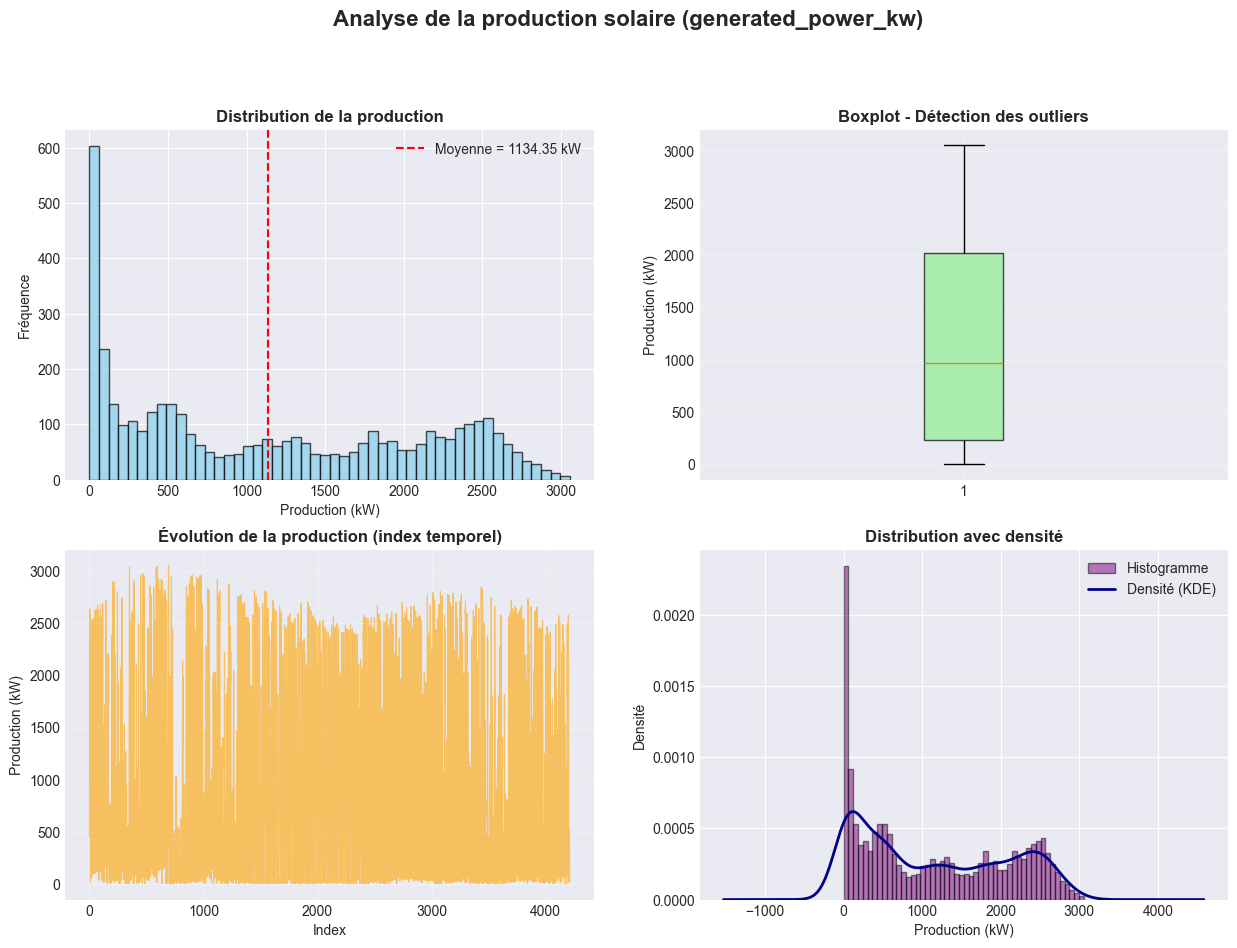

In [25]:
# ============================================
# SECTION 4 : VISUALISATIONS EXPLORATOIRES
# ============================================

print("="*60)
print(" VISUALISATION DE LA PRODUCTION SOLAIRE")
print("="*60)

# Création de la figure avec plusieurs graphiques
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Analyse de la production solaire (generated_power_kw)', 
             fontsize=16, fontweight='bold', y=1.00)

# 1. Histogramme
axes[0, 0].hist(df['generated_power_kw'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution de la production', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Production (kW)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(df['generated_power_kw'].mean(), color='red', linestyle='--', 
                   label=f'Moyenne = {df["generated_power_kw"].mean():.2f} kW')
axes[0, 0].legend()

# 2. Boxplot
axes[0, 1].boxplot(df['generated_power_kw'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[0, 1].set_title('Boxplot - Détection des outliers', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Production (kW)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Évolution temporelle (si on a l'index comme temps)
axes[1, 0].plot(df.index, df['generated_power_kw'], color='orange', alpha=0.6, linewidth=0.8)
axes[1, 0].set_title('Évolution de la production (index temporel)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Index')
axes[1, 0].set_ylabel('Production (kW)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Densité (KDE)
axes[1, 1].hist(df['generated_power_kw'], bins=50, density=True, alpha=0.5, 
                color='purple', edgecolor='black', label='Histogramme')
df['generated_power_kw'].plot(kind='kde', ax=axes[1, 1], color='darkblue', 
                               linewidth=2, label='Densité (KDE)')
axes[1, 1].set_title('Distribution avec densité', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Production (kW)')
axes[1, 1].set_ylabel('Densité')
axes[1, 1].legend()





In [26]:
# ============================================
# SECTION 5 : ANALYSE DES CORRÉLATIONS
# ============================================

print("="*60)
print(" ANALYSE DES CORRÉLATIONS")
print("="*60)

# Calcul de la matrice de corrélation
correlation_matrix = df.corr()

# Corrélations avec la variable cible
target_corr = correlation_matrix['generated_power_kw'].sort_values(ascending=False)

print("\n Top 10 des variables les PLUS corrélées avec generated_power_kw :\n")
print(target_corr.head(10).to_string())



 ANALYSE DES CORRÉLATIONS

 Top 10 des variables les PLUS corrélées avec generated_power_kw :

generated_power_kw                   1.000000
shortwave_radiation_backwards_sfc    0.556148
temperature_2_m_above_gnd            0.217280
mean_sea_level_pressure_MSL          0.150551
snowfall_amount_sfc                 -0.049508
azimuth                             -0.061184
wind_direction_80_m_above_gnd       -0.069941
wind_direction_10_m_above_gnd       -0.073257
wind_direction_900_mb               -0.077435
wind_speed_10_m_above_gnd           -0.083043


In [27]:

print("\nTop 10 des variables les MOINS corrélées avec generated_power_kw :\n")
print(target_corr.tail(10).to_string())




Top 10 des variables les MOINS corrélées avec generated_power_kw :

total_precipitation_sfc           -0.118442
wind_gust_10_m_above_gnd          -0.122808
high_cloud_cover_high_cld_lay     -0.147723
wind_speed_80_m_above_gnd         -0.157899
medium_cloud_cover_mid_cld_lay    -0.227834
low_cloud_cover_low_cld_lay       -0.288066
total_cloud_cover_sfc             -0.334338
relative_humidity_2_m_above_gnd   -0.336783
angle_of_incidence                -0.646537
zenith                            -0.649991



 Génération de la heatmap des corrélations


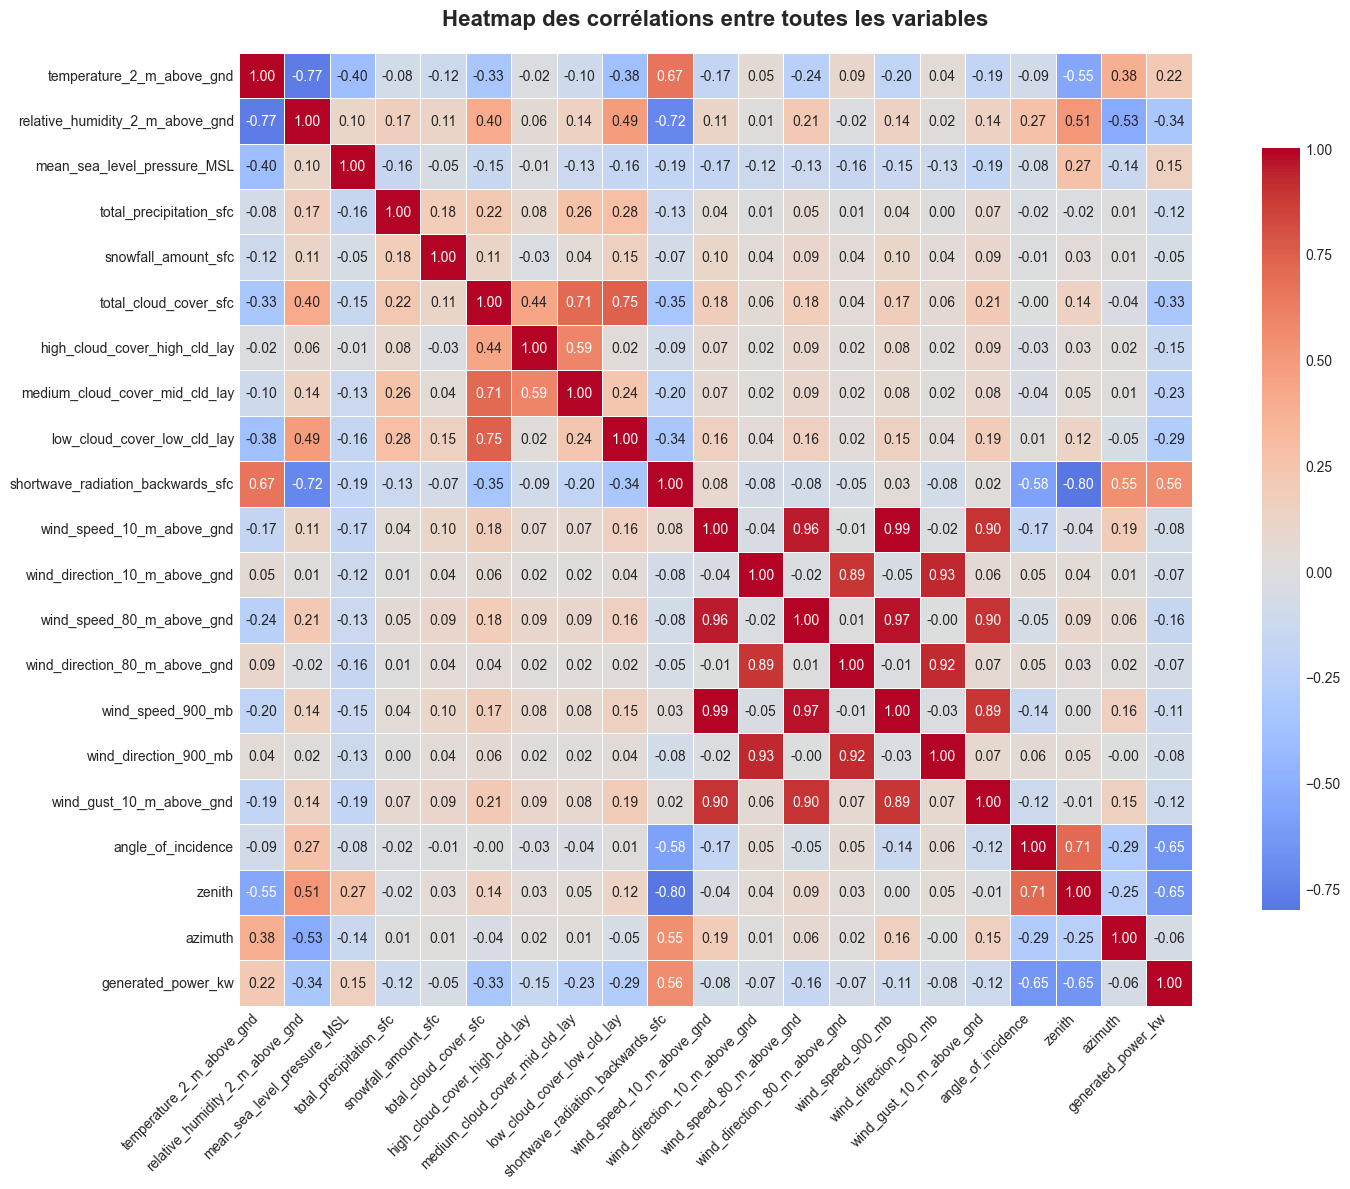


Corrélations avec generated_power_kw (graphique)


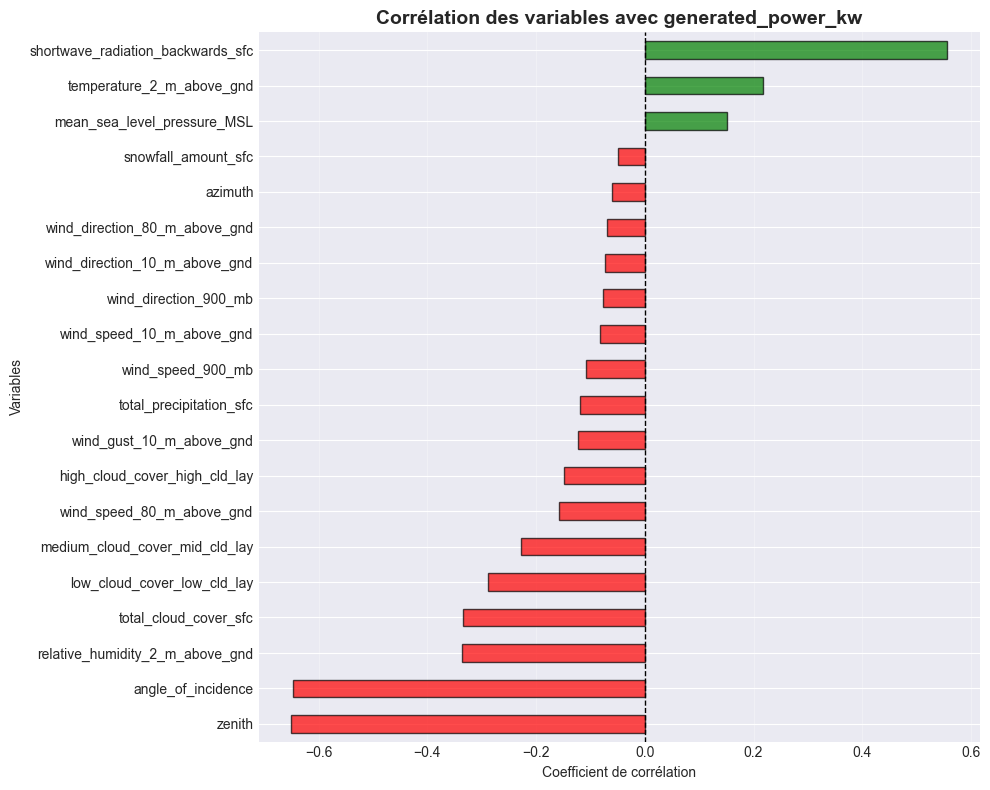

In [29]:
# Visualisation de la heatmap
print("\n" + "="*60)
print(" Génération de la heatmap des corrélations")
print("="*60)

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Heatmap des corrélations entre toutes les variables', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('Outputs/02_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# Visualisation spécifique pour la variable cible
print("\n" + "="*60)
print("Corrélations avec generated_power_kw (graphique)")
print("="*60)

plt.figure(figsize=(10, 8))
target_corr_sorted = target_corr.drop('generated_power_kw').sort_values()
colors = ['red' if x < 0 else 'green' for x in target_corr_sorted.values]
target_corr_sorted.plot(kind='barh', color=colors, edgecolor='black', alpha=0.7)
plt.title('Corrélation des variables avec generated_power_kw', 
          fontsize=14, fontweight='bold')
plt.xlabel('Coefficient de corrélation')
plt.ylabel('Variables')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('Outputs/03_target_correlations.png', dpi=300, bbox_inches='tight')
plt.show()



In [30]:
# ============================================
# SECTION 6 : DÉTECTION DES OUTLIERS
# ============================================

print("="*60)
print("DÉTECTION DES OUTLIERS")
print("="*60)

# Fonction pour détecter les outliers avec la méthode IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analyse des outliers pour generated_power_kw
outliers, lower, upper = detect_outliers_iqr(df, 'generated_power_kw')

print(f"\nAnalyse de generated_power_kw :")
print(f"   Q1 (25%)           : {df['generated_power_kw'].quantile(0.25):.2f} kW")
print(f"   Q3 (75%)           : {df['generated_power_kw'].quantile(0.75):.2f} kW")
print(f"   IQR                : {df['generated_power_kw'].quantile(0.75) - df['generated_power_kw'].quantile(0.25):.2f} kW")
print(f"   Borne inférieure   : {lower:.2f} kW")
print(f"   Borne supérieure   : {upper:.2f} kW")
print(f"   Nombre d'outliers  : {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")







DÉTECTION DES OUTLIERS

Analyse de generated_power_kw :
   Q1 (25%)           : 231.70 kW
   Q3 (75%)           : 2020.97 kW
   IQR                : 1789.27 kW
   Borne inférieure   : -2452.20 kW
   Borne supérieure   : 4704.87 kW
   Nombre d'outliers  : 0 (0.00%)


In [31]:
# Compter les outliers pour toutes les variables numériques
print("\n" + "="*60)
print("OUTLIERS DANS TOUTES LES VARIABLES")
print("="*60)

outlier_summary = []
for col in df.select_dtypes(include=[np.number]).columns:
    outliers_col, _, _ = detect_outliers_iqr(df, col)
    outlier_summary.append({
        'Variable': col,
        'Nombre outliers': len(outliers_col),
        'Pourcentage (%)': f"{len(outliers_col)/len(df)*100:.2f}"
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Nombre outliers', ascending=False)
print(outlier_df.to_string(index=False))


OUTLIERS DANS TOUTES LES VARIABLES
                         Variable  Nombre outliers Pourcentage (%)
   medium_cloud_cover_mid_cld_lay              959           22.76
      low_cloud_cover_low_cld_lay              955           22.67
    high_cloud_cover_high_cld_lay              773           18.35
          total_precipitation_sfc              307            7.29
         wind_gust_10_m_above_gnd              127            3.01
                wind_speed_900_mb              103            2.44
        wind_speed_10_m_above_gnd              101            2.40
        wind_speed_80_m_above_gnd               74            1.76
              snowfall_amount_sfc               47            1.12
      mean_sea_level_pressure_MSL               45            1.07
                           zenith               10            0.24
  relative_humidity_2_m_above_gnd                0            0.00
        temperature_2_m_above_gnd                0            0.00
    wind_direction_10_m_ab


Visualisation des outliers (variables clés)


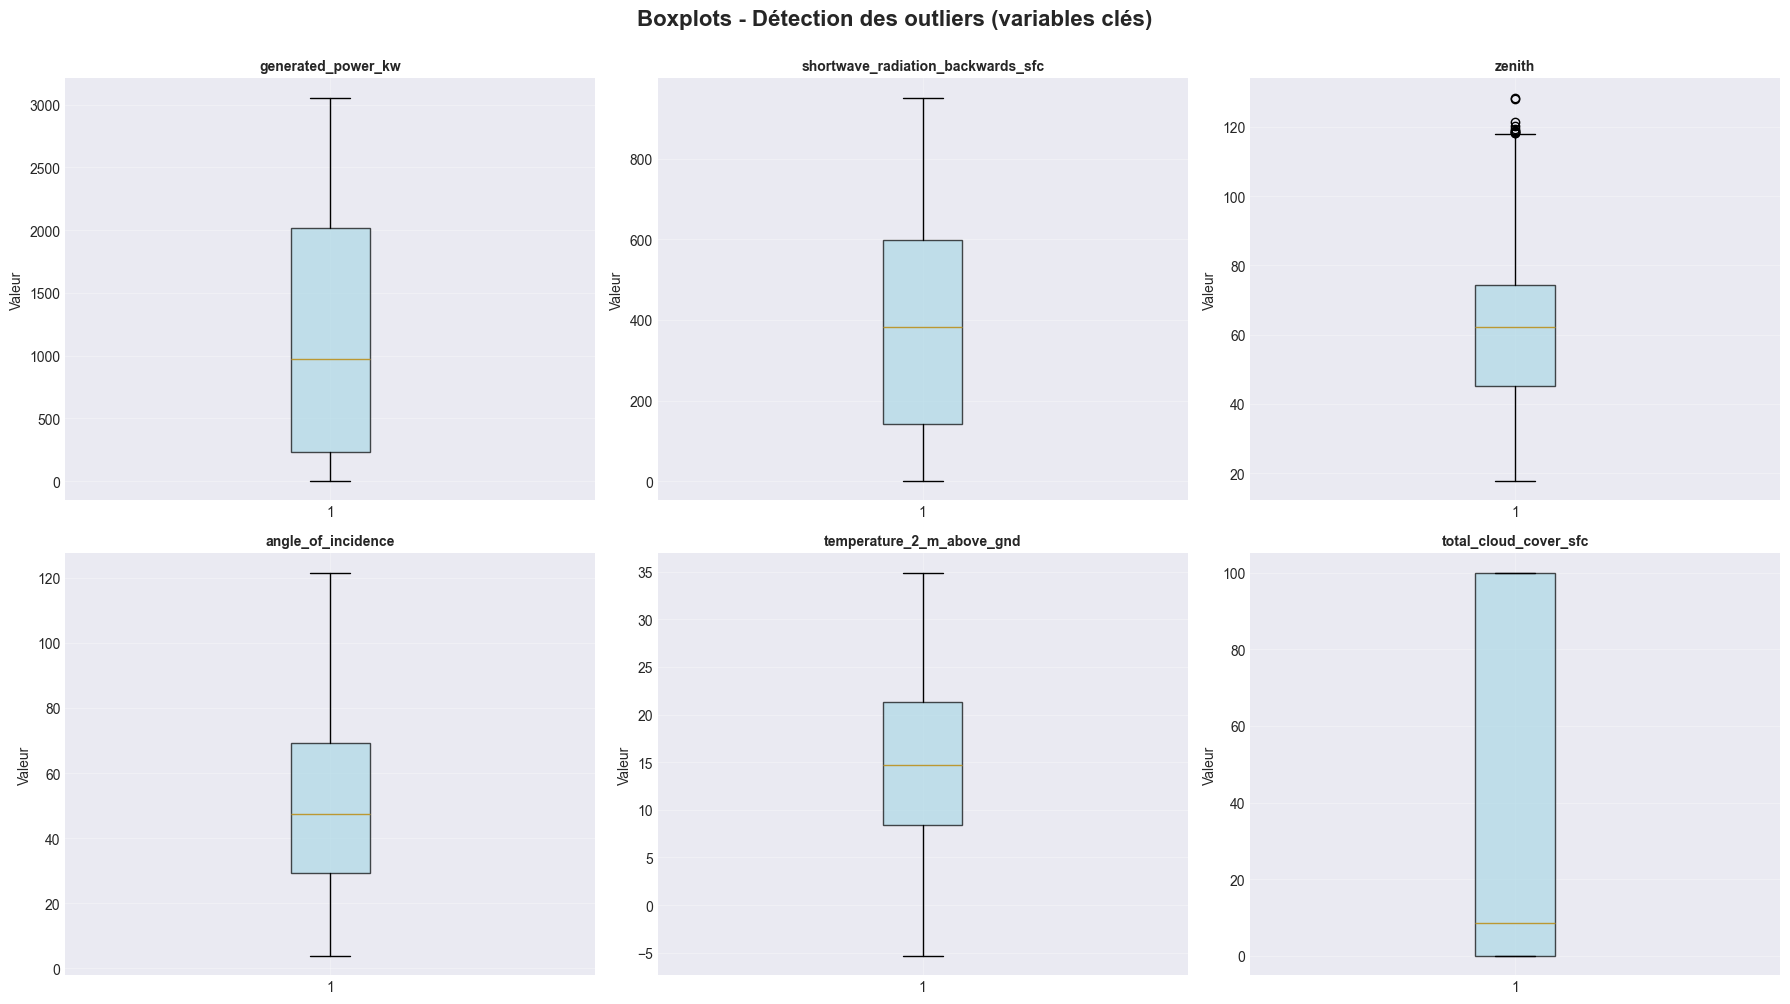

In [32]:
# Visualisation des outliers pour les variables principales
print("\n" + "="*60)
print("Visualisation des outliers (variables clés)")
print("="*60)

# Sélection des variables les plus corrélées
top_vars = ['generated_power_kw', 'shortwave_radiation_backwards_sfc', 
            'zenith', 'angle_of_incidence', 'temperature_2_m_above_gnd',
            'total_cloud_cover_sfc']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Boxplots - Détection des outliers (variables clés)', 
             fontsize=16, fontweight='bold', y=1.00)

for idx, var in enumerate(top_vars):
    row = idx // 3
    col = idx % 3
    axes[row, col].boxplot(df[var], vert=True, patch_artist=True,
                           boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[row, col].set_title(var, fontsize=10, fontweight='bold')
    axes[row, col].set_ylabel('Valeur')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Outputs/04_outliers_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# ============================================
# SECTION 7 : FEATURE ENGINEERING
# ============================================

print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Copie du dataframe pour ne pas modifier l'original
df_engineered = df.copy()

print("\nCréation de nouvelles features...")

# 1. Interaction entre radiation et température
df_engineered['radiation_temp_interaction'] = (
    df_engineered['shortwave_radiation_backwards_sfc'] * 
    df_engineered['temperature_2_m_above_gnd']
)
print("1. radiation_temp_interaction créée")

# 2. Couverture nuageuse totale (somme des 3 couches)
df_engineered['total_cloud_all_layers'] = (
    df_engineered['high_cloud_cover_high_cld_lay'] +
    df_engineered['medium_cloud_cover_mid_cld_lay'] +
    df_engineered['low_cloud_cover_low_cld_lay']
)
print("2. total_cloud_all_layers créée")

# 3. Ratio humidité/température (indicateur de confort)
df_engineered['humidity_temp_ratio'] = (
    df_engineered['relative_humidity_2_m_above_gnd'] / 
    (df_engineered['temperature_2_m_above_gnd'] + 273.15)  # Kelvin
)
print("3. humidity_temp_ratio créée")

# 4. Vitesse du vent moyenne (3 niveaux)
df_engineered['avg_wind_speed'] = (
    df_engineered['wind_speed_10_m_above_gnd'] +
    df_engineered['wind_speed_80_m_above_gnd'] +
    df_engineered['wind_speed_900_mb']
) / 3
print("4. avg_wind_speed créée")

# 5. Indicateur de conditions optimales (radiation haute + nuages bas)
df_engineered['optimal_conditions'] = (
    (df_engineered['shortwave_radiation_backwards_sfc'] > 
     df_engineered['shortwave_radiation_backwards_sfc'].quantile(0.75)) &
    (df_engineered['total_cloud_cover_sfc'] < 
     df_engineered['total_cloud_cover_sfc'].quantile(0.25))
).astype(int)
print("5. optimal_conditions créée (variable binaire)")

# 6. Angle solaire optimal (zenith faible = production haute)
df_engineered['low_zenith'] = (
    df_engineered['zenith'] < df_engineered['zenith'].quantile(0.25)
).astype(int)
print("6. low_zenith créée (variable binaire)")

# 7. Précipitations totales (pluie + neige)
df_engineered['total_precip'] = (
    df_engineered['total_precipitation_sfc'] + 
    df_engineered['snowfall_amount_sfc']
)
print("7. total_precip créée")

print("\n" + "="*60)
print("RÉSUMÉ DU DATASET ENRICHI")
print("="*60)
print(f"Nombre de colonnes AVANT : {df.shape[1]}")
print(f"Nombre de colonnes APRÈS : {df_engineered.shape[1]}")
print(f"Nouvelles features créées : {df_engineered.shape[1] - df.shape[1]}")



FEATURE ENGINEERING

Création de nouvelles features...
1. radiation_temp_interaction créée
2. total_cloud_all_layers créée
3. humidity_temp_ratio créée
4. avg_wind_speed créée
5. optimal_conditions créée (variable binaire)
6. low_zenith créée (variable binaire)
7. total_precip créée

RÉSUMÉ DU DATASET ENRICHI
Nombre de colonnes AVANT : 21
Nombre de colonnes APRÈS : 28
Nouvelles features créées : 7


In [35]:
print("\nListe des nouvelles features :")
new_features = [col for col in df_engineered.columns if col not in df.columns]
for i, feat in enumerate(new_features, 1):
    print(f"{i}. {feat}")


# Corrélations des nouvelles features avec la cible
print("\n" + "="*60)
print(" CORRÉLATIONS DES NOUVELLES FEATURES AVEC generated_power_kw")
print("="*60)
new_correlations = df_engineered[new_features + ['generated_power_kw']].corr()['generated_power_kw'].drop('generated_power_kw').sort_values(ascending=False)
print(new_correlations.to_string())




Liste des nouvelles features :
1. radiation_temp_interaction
2. total_cloud_all_layers
3. humidity_temp_ratio
4. avg_wind_speed
5. optimal_conditions
6. low_zenith
7. total_precip

 CORRÉLATIONS DES NOUVELLES FEATURES AVEC generated_power_kw
low_zenith                    0.472614
radiation_temp_interaction    0.417103
avg_wind_speed               -0.120089
total_precip                 -0.121699
total_cloud_all_layers       -0.313545
humidity_temp_ratio          -0.336931
optimal_conditions                 NaN


In [36]:
# ============================================
# SECTION 8 : SÉLECTION DES FEATURES
# ============================================

print("="*60)
print("SÉLECTION DES MEILLEURES FEATURES")
print("="*60)

# Calculer toutes les corrélations avec la cible
all_correlations = df_engineered.corr()['generated_power_kw'].drop('generated_power_kw').abs().sort_values(ascending=False)

print("\nTop 15 des features les plus corrélées (valeur absolue) :\n")
print(all_correlations.head(15).to_string())



SÉLECTION DES MEILLEURES FEATURES

Top 15 des features les plus corrélées (valeur absolue) :

zenith                               0.649991
angle_of_incidence                   0.646537
shortwave_radiation_backwards_sfc    0.556148
low_zenith                           0.472614
radiation_temp_interaction           0.417103
humidity_temp_ratio                  0.336931
relative_humidity_2_m_above_gnd      0.336783
total_cloud_cover_sfc                0.334338
total_cloud_all_layers               0.313545
low_cloud_cover_low_cld_lay          0.288066
medium_cloud_cover_mid_cld_lay       0.227834
temperature_2_m_above_gnd            0.217280
wind_speed_80_m_above_gnd            0.157899
mean_sea_level_pressure_MSL          0.150551
high_cloud_cover_high_cld_lay        0.147723


In [37]:
# Sélection des features à garder (corrélation > 0.1 OU nouvelles features pertinentes)
selected_features = all_correlations[all_correlations > 0.1].index.tolist()

# Ajouter quelques features importantes même si corrélation < 0.1
important_features = ['temperature_2_m_above_gnd', 'mean_sea_level_pressure_MSL', 
                      'avg_wind_speed', 'total_precip']
for feat in important_features:
    if feat not in selected_features and feat in df_engineered.columns:
        selected_features.append(feat)

print("\n" + "="*60)
print("FEATURES SÉLECTIONNÉES POUR LA MODÉLISATION")
print("="*60)
print(f"Nombre de features sélectionnées : {len(selected_features)}\n")

for i, feat in enumerate(selected_features, 1):
    corr_value = df_engineered.corr()['generated_power_kw'][feat]
    print(f"{i:2d}. {feat:45s} | Corrélation : {corr_value:+.4f}")

# Création du dataset final pour la modélisation
X = df_engineered[selected_features]
y = df_engineered['generated_power_kw']




FEATURES SÉLECTIONNÉES POUR LA MODÉLISATION
Nombre de features sélectionnées : 20

 1. zenith                                        | Corrélation : -0.6500
 2. angle_of_incidence                            | Corrélation : -0.6465
 3. shortwave_radiation_backwards_sfc             | Corrélation : +0.5561
 4. low_zenith                                    | Corrélation : +0.4726
 5. radiation_temp_interaction                    | Corrélation : +0.4171
 6. humidity_temp_ratio                           | Corrélation : -0.3369
 7. relative_humidity_2_m_above_gnd               | Corrélation : -0.3368
 8. total_cloud_cover_sfc                         | Corrélation : -0.3343
 9. total_cloud_all_layers                        | Corrélation : -0.3135
10. low_cloud_cover_low_cld_lay                   | Corrélation : -0.2881
11. medium_cloud_cover_mid_cld_lay                | Corrélation : -0.2278
12. temperature_2_m_above_gnd                     | Corrélation : +0.2173
13. wind_speed_80_m_above_gn

In [38]:
print("\n" + "="*60)
print("DATASET FINAL PRÊT POUR LA MODÉLISATION")
print("="*60)
print(f"Shape de X (features) : {X.shape}")
print(f"Shape de y (target)   : {y.shape}")

# Vérification finale
print("\n" + "="*60)
print("VÉRIFICATION FINALE")
print("="*60)
print(f"Valeurs manquantes dans X : {X.isnull().sum().sum()}")
print(f"Valeurs manquantes dans y : {y.isnull().sum()}")
print(f"Valeurs infinies dans X   : {np.isinf(X).sum().sum()}")

print("\nDataset final vérifié et prêt !")
print("="*60)


DATASET FINAL PRÊT POUR LA MODÉLISATION
Shape de X (features) : (4213, 20)
Shape de y (target)   : (4213,)

VÉRIFICATION FINALE
Valeurs manquantes dans X : 0
Valeurs manquantes dans y : 0
Valeurs infinies dans X   : 0

Dataset final vérifié et prêt !


In [39]:
# ============================================
# SECTION 9 : PRÉPARATION FINALE ET EXPORT
# ============================================

print("="*60)
print("SAUVEGARDE DU DATASET NETTOYÉ")
print("="*60)

# Création du dataset final avec les features sélectionnées + la cible
final_dataset = df_engineered[selected_features + ['generated_power_kw']].copy()

# Informations avant sauvegarde
print(f"\nInformations sur le dataset final :")
print(f"   Dimensions        : {final_dataset.shape[0]} lignes × {final_dataset.shape[1]} colonnes")
print(f"   Features (X)      : {len(selected_features)} colonnes")
print(f"   Target (y)        : 1 colonne (generated_power_kw)")
print(f"   Taille mémoire    : {final_dataset.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   Valeurs manquantes: {final_dataset.isnull().sum().sum()}")

# Sauvegarde en CSV
output_path = 'Data/cleaned_data.csv'
final_dataset.to_csv(output_path, index=False)

print(f"\nDataset sauvegardé : {output_path}")

# Vérification de la sauvegarde
df_check = pd.read_csv(output_path)
print(f"\n🔍 Vérification de la sauvegarde :")
print(f"   Fichier chargé    : {df_check.shape[0]} lignes × {df_check.shape[1]} colonnes")





SAUVEGARDE DU DATASET NETTOYÉ

Informations sur le dataset final :
   Dimensions        : 4213 lignes × 21 colonnes
   Features (X)      : 20 colonnes
   Target (y)        : 1 colonne (generated_power_kw)
   Taille mémoire    : 0.68 MB
   Valeurs manquantes: 0

Dataset sauvegardé : Data/cleaned_data.csv

🔍 Vérification de la sauvegarde :
   Fichier chargé    : 4213 lignes × 21 colonnes


In [41]:
# Résumé des features pour le fichier suivant
print("\n" + "="*60)
print("📋 RÉSUMÉ POUR LE FICHIER 02_modeling.ipynb")
print("="*60)
print(f"Dataset à charger : Data/cleaned_data.csv")
print(f"Nombre de features: {len(selected_features)}")
print(f"Variable cible    : generated_power_kw")
print(f"Nombre total      : {final_dataset.shape[0]} observations")

# Liste des features pour référence
print("\nListe des features à utiliser dans le modèle :")
print("-" * 60)
for i, feat in enumerate(selected_features, 1):
    print(f"{i:2d}. {feat}")



📋 RÉSUMÉ POUR LE FICHIER 02_modeling.ipynb
Dataset à charger : Data/cleaned_data.csv
Nombre de features: 20
Variable cible    : generated_power_kw
Nombre total      : 4213 observations

Liste des features à utiliser dans le modèle :
------------------------------------------------------------
 1. zenith
 2. angle_of_incidence
 3. shortwave_radiation_backwards_sfc
 4. low_zenith
 5. radiation_temp_interaction
 6. humidity_temp_ratio
 7. relative_humidity_2_m_above_gnd
 8. total_cloud_cover_sfc
 9. total_cloud_all_layers
10. low_cloud_cover_low_cld_lay
11. medium_cloud_cover_mid_cld_lay
12. temperature_2_m_above_gnd
13. wind_speed_80_m_above_gnd
14. mean_sea_level_pressure_MSL
15. high_cloud_cover_high_cld_lay
16. wind_gust_10_m_above_gnd
17. total_precip
18. avg_wind_speed
19. total_precipitation_sfc
20. wind_speed_900_mb
